¡Tablas cargadas desde GitHub!


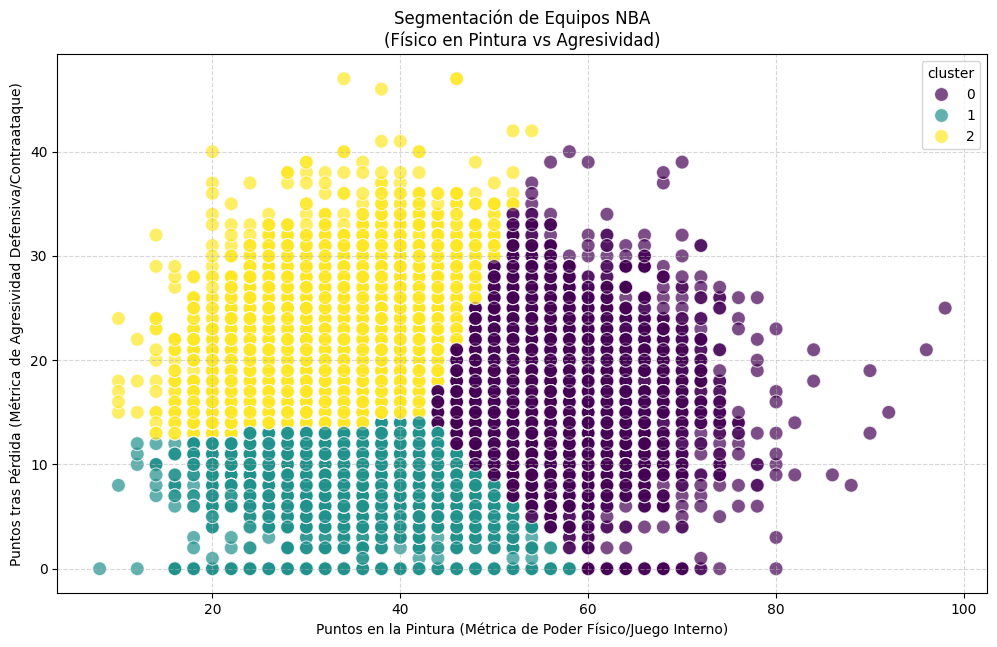

--- Resumen de los Clústeres ---
         pts_paint_home  pts_off_to_home
cluster                                 
0             53.148242        16.309898
1             37.560720         7.781509
2             35.565616        20.264336


In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. EXTRACCIÓN DE DATOS (URLs RAW)
base_url = "https://raw.githubusercontent.com/drcornejo19/PF-NBA-Scouting-Analytics/main/data/raw/"

try:
    df_stats = pd.read_csv(base_url + "other_stats.csv")
    df_teams = pd.read_csv(base_url + "team.csv")
    print("¡Tablas cargadas desde GitHub!")

    # 2. LIMPIEZA DE COLUMNAS (Elimina espacios invisibles)
    df_stats.columns = df_stats.columns.str.strip()
    df_teams.columns = df_teams.columns.str.strip()

    # 3. UNIÓN DE TABLAS (Merge)
    # Unimos por ID de equipo (team_id_home en stats y id en team)
    df_master = pd.merge(df_stats, df_teams, left_on='team_id_home', right_on='id')

    # 4. PREPARACIÓN PARA MACHINE LEARNING
    # Usamos variables confirmadas: Puntos en la Pintura y Puntos por Pérdidas
    features = ['pts_paint_home', 'pts_off_to_home']
    df_ml = df_master[features].dropna()

    # Escalado de datos (Crucial para K-Means)
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(df_ml)

    # 5. APLICACIÓN DE K-MEANS (3 Grupos)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    df_ml['cluster'] = kmeans.fit_predict(df_scaled)

   # 6. VISUALIZACIÓN DE RESULTADOS
    plt.figure(figsize=(12, 7))
    sns.scatterplot(data=df_ml, x='pts_paint_home', y='pts_off_to_home', 
                    hue='cluster', palette='viridis', s=100, alpha=0.7)
    
    plt.title('Segmentación de Equipos NBA\n(Físico en Pintura vs Agresividad)')
    plt.xlabel('Puntos en la Pintura (Métrica de Poder Físico/Juego Interno)')
    plt.ylabel('Puntos tras Pérdida (Métrica de Agresividad Defensiva/Contraataque)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    print("--- Resumen de los Clústeres ---")
    print(df_ml.groupby('cluster').mean())

except Exception as e:
    print(f"Ocurrió un error: {e}")
